In [67]:
import sys
sys.path.insert(0, "..")

# Dispersion Trade: θ/Γ/ν-Neutral Backtest

## 1. Introduction & Theoretical Framework

### What is a dispersion trade?

A **long dispersion trade** consists in:
- **Short volatility** on the index (SPY) — the carry leg
- **Long volatility** on one component (AAPL) — the dispersion leg

This strategy has a **short correlation exposure**: it profits when the realized correlation between index components is lower than the implied correlation priced by options.

### Why does it work?

The fundamental relationship underlying the trade is the index variance decomposition:

$$\sigma_{\text{index}}^2 = \sum_i \sum_j w_i w_j \rho_{ij} \sigma_i \sigma_j$$

Empirically, implied correlation extracted from index options **systematically exceeds** realized correlation (Driessen, Maenhout & Vilkov, 2009). This **correlation risk premium** generates profit for long dispersion traders on average.

### When does it lose?

The trade loses when correlation **spikes** — typically during market crises (e.g. Covid March 2020), when all stocks sell off together and realized correlation approaches 1.

### Greek-neutral sizing

To size the two legs correctly, we match the greek notional of the short index leg with the long component leg. We implement 3 flavors:

- **θ-neutral**: $N_{\text{AAPL}} = \frac{|\Theta^{\text{total}}_{\text{SPY}}|}{|\Theta^{\text{unit}}_{\text{AAPL}}|}$ — Both legs decay at the same rate. The net carry is neutralized, isolating correlation exposure.

- **Γ-neutral (dollar gamma)**: $N_{\text{AAPL}} = \frac{|\Gamma^{\text{total}}_{\text{SPY}} \times S^2_{\text{SPY}}|}{|\Gamma^{\text{unit}}_{\text{AAPL}} \times S^2_{\text{AAPL}}|}$ — We use **dollar-gamma** ($\Gamma \times S^2$) because raw gamma is not comparable across underliers with different spot prices.

- **ν-neutral**: $N_{\text{AAPL}} = \frac{|\mathcal{V}^{\text{total}}_{\text{SPY}}|}{|\mathcal{V}^{\text{unit}}_{\text{AAPL}}|}$ — Neutral in directional volatility exposure, isolating the pure correlation component.

### References

- Driessen, Maenhout & Vilkov (2009), *The Price of Correlation Risk: Evidence from Equity Options*, Journal of Finance
- Bossu (2014), *Advanced Equity Derivatives: Volatility and Correlation*, Wiley Finance
- Schneider & Stübinger (2020), *Dispersion Trading Based on the Explanatory Power of S&P 500 Stock Returns*, Mathematics (MDPI)

---
## 2. Setup & Configuration

In [63]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from datetime import datetime
from warnings import filterwarnings
import logging

matplotlib.rc("font", **{"size": 14})
logging.basicConfig(level=logging.WARNING, format="%(asctime)s | %(levelname)s | %(message)s")
filterwarnings("ignore")

# Project imports
from src.data.option_db import SPYOptionLoader, AAPLOptionLoader, extract_spot_from_options
from src.data.rates_db import USRatesLoader
from src.metrics.performance import (
    realized_returns, sharpe_ratio, max_drawdown, drawdown, calmar_ratio,
)
from src.metrics.volatility import realized_volatility

# Dispersion imports
from src.dispersion.dispersion_trade import (
    run_dispersion_backtest,
    generate_dispersion_trades,
    DispersionBacktester,
    INDEX_SHORT_STRADDLE_1M,
    COMPONENT_LONG_STRADDLE_1M,
)
from src.dispersion.greek_sizing import compute_greek_notional, compute_sizing_ratio

print("All imports successful.")

All imports successful.


In [65]:
# ── Backtest parameters ──
# AAPL had a 4:1 stock split on Aug 31, 2020.
# Pre-split data creates artificial volatility that distorts sizing ratios.
# We start the backtest after the split to avoid this data artifact.
START_DATE = datetime(2020, 9, 1)
END_DATE   = datetime(2022, 12, 30)

INDEX_TICKER     = "SPY"
COMPONENT_TICKER = "AAPL"

GREEKS_TO_TEST = ["theta", "gamma", "vega"]

# Color palette for consistent plots
FLAVOR_COLORS = {
    "theta": "#534AB7",  # purple
    "gamma": "#1D9E75",  # teal
    "vega":  "#D85A30",  # coral
}

print(f"Backtest period: {START_DATE.date()} → {END_DATE.date()}")
print(f"Index: {INDEX_TICKER} (short vol) vs Component: {COMPONENT_TICKER} (long vol)")
print(f"Flavors: {GREEKS_TO_TEST}")

Backtest period: 2020-09-01 → 2022-12-30
Index: SPY (short vol) vs Component: AAPL (long vol)
Flavors: ['theta', 'gamma', 'vega']


**Note on AAPL 4:1 stock split (August 31, 2020):**

The AAPL option data is not split-adjusted. The spot price drops from ~\$500 to ~\$125 overnight on the split date, creating artificial extreme returns that are not real market volatility. This distorts the greek sizing ratios, particularly for vega-neutral where the unit vega changes dramatically with the spot level.

To avoid this data artifact, we start the backtest on **September 1, 2020** (post-split). This gives us 2+ years of clean data (Sept 2020 – Dec 2022) covering both the post-Covid recovery and the 2022 bear market.

---
## 3. Quick Data Check

Before running the dispersion backtest, let's verify that the underlying data loads correctly and the date ranges align.

SPY options  : 5,626,758 rows | 591 dates
AAPL options : 1,152,648 rows | 590 dates
Common dates : 590 dates
Date range   : 2020-09-01 → 2022-12-30


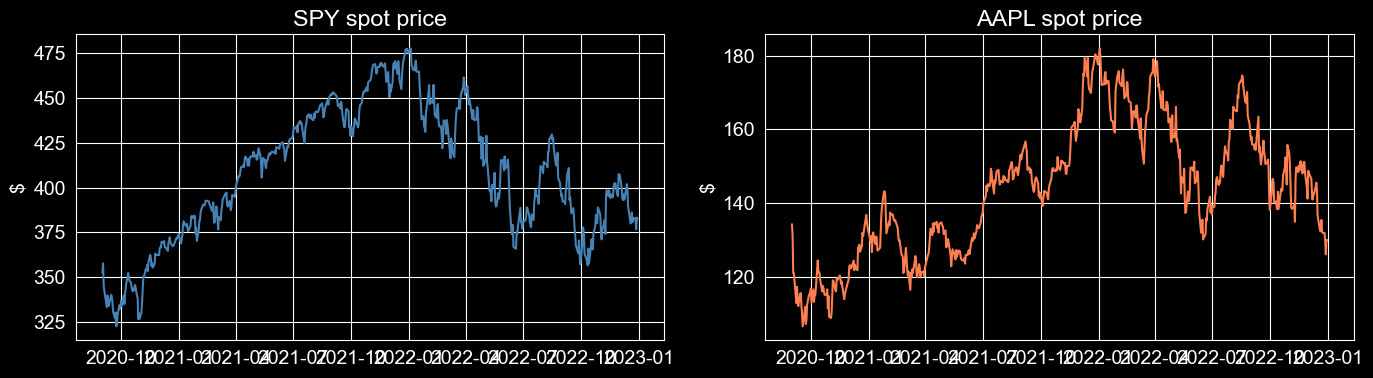

In [66]:
# Quick verification: load raw data to confirm alignment
df_spy_raw = SPYOptionLoader.load_data(
    start_date=START_DATE, end_date=END_DATE, process_kwargs={"ticker": "SPY"}
)
df_aapl_raw = AAPLOptionLoader.load_data(
    start_date=START_DATE, end_date=END_DATE, process_kwargs={"ticker": "AAPL"}
)

spy_dates  = set(df_spy_raw["date"].unique())
aapl_dates = set(df_aapl_raw["date"].unique())
common     = spy_dates & aapl_dates

print(f"SPY options  : {df_spy_raw.shape[0]:>8,} rows | {len(spy_dates)} dates")
print(f"AAPL options : {df_aapl_raw.shape[0]:>8,} rows | {len(aapl_dates)} dates")
print(f"Common dates : {len(common)} dates")
print(f"Date range   : {min(common).date()} → {max(common).date()}")

# Plot spot prices side by side
df_spy_spot  = extract_spot_from_options(df_spy_raw)
df_aapl_spot = extract_spot_from_options(df_aapl_raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(df_spy_spot["date"], df_spy_spot["spot"], color="steelblue")
axes[0].set_title("SPY spot price"); axes[0].set_ylabel("$")
axes[1].plot(df_aapl_spot["date"], df_aapl_spot["spot"], color="coral")
axes[1].set_title("AAPL spot price"); axes[1].set_ylabel("$")
plt.tight_layout(); plt.show()

# Free memory
del df_spy_raw, df_aapl_raw

---
## 4. Running Dispersion Backtests

We now run the full dispersion backtest pipeline for each greek flavor.

For each flavor, `run_dispersion_backtest()` performs:
1. Generate trades for the **short SPY straddle** (index leg) and **long AAPL straddle** (component leg)
2. Apply **greek-neutral sizing** to rescale the component leg weights
3. **Delta-hedge** each leg independently (SPY shares and AAPL shares)
4. Run the **backtest** with bid-ask transaction costs

In [51]:
# ── Run backtest for each greek flavor ──
backtests: dict[str, DispersionBacktester] = {}

for greek in GREEKS_TO_TEST:
    print(f"\n{'='*60}")
    print(f"  Running {greek}-neutral dispersion backtest")
    print(f"{'='*60}")
    
    bt = run_dispersion_backtest(
        start_date=START_DATE,
        end_date=END_DATE,
        index_ticker=INDEX_TICKER,
        component_ticker=COMPONENT_TICKER,
        greek=greek,
        base_notional=1.0,
    )
    backtests[greek] = bt
    print(f"  ✓ {greek}-neutral: {len(bt.pnl)} P&L days")

print(f"\n{'='*60}")
print(f"  All {len(backtests)} backtests completed.")
print(f"{'='*60}")


  Running theta-neutral dispersion backtest


100%|██████████| 608/608 [00:03<00:00, 178.76it/s]


  ✓ theta-neutral: 609 P&L days

  Running gamma-neutral dispersion backtest


100%|██████████| 608/608 [00:03<00:00, 178.59it/s]


  ✓ gamma-neutral: 609 P&L days

  Running vega-neutral dispersion backtest


100%|██████████| 608/608 [00:03<00:00, 176.90it/s]


  ✓ vega-neutral: 609 P&L days

  All 3 backtests completed.


---
## 5. Performance Analysis

### 5.1 Cumulative P&L comparison

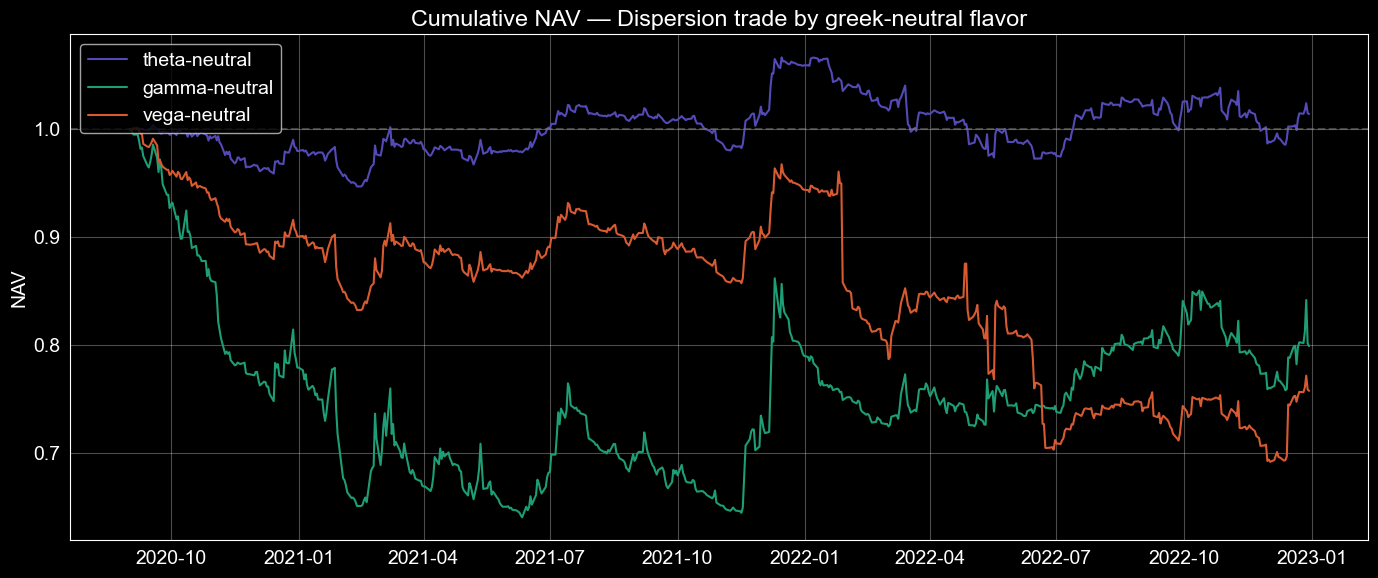

In [52]:
fig, ax = plt.subplots(figsize=(14, 6))

for greek, bt in backtests.items():
    nav = bt.nav["NAV"]
    ax.plot(nav.index, nav, label=f"{greek}-neutral", color=FLAVOR_COLORS[greek], linewidth=1.5)

ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
ax.set_title("Cumulative NAV — Dispersion trade by greek-neutral flavor")
ax.set_ylabel("NAV")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 5.2 Performance metrics table

In [53]:
# Compute daily returns from NAV for each flavor
metrics_rows = []

for greek, bt in backtests.items():
    nav = bt.nav["NAV"]
    daily_returns = nav.pct_change().dropna()
    
    metrics_rows.append({
        "Flavor": f"{greek}-neutral",
        "Ann. Return (%)": round(realized_returns(daily_returns) * 100, 2),
        "Ann. Volatility (%)": round(realized_volatility(daily_returns) * 100, 2),
        "Sharpe Ratio": round(sharpe_ratio(daily_returns), 3),
        "Max Drawdown (%)": round(max_drawdown(daily_returns) * 100, 2),
        "Calmar Ratio": round(calmar_ratio(daily_returns), 3),
        "Final NAV": round(nav.iloc[-1], 4),
    })

df_metrics = pd.DataFrame(metrics_rows).set_index("Flavor")
df_metrics

,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%),Calmar Ratio,Final NAV
Flavor,,,,,,
theta-neutral,0.85,7.37,0.116,-8.80,0.097,1.0142
gamma-neutral,-7.01,21.49,-0.326,-35.94,-0.195,0.7992
vega-neutral,-10.17,16.23,-0.627,-30.81,-0.330,0.7578


### 5.3 Drawdown comparison

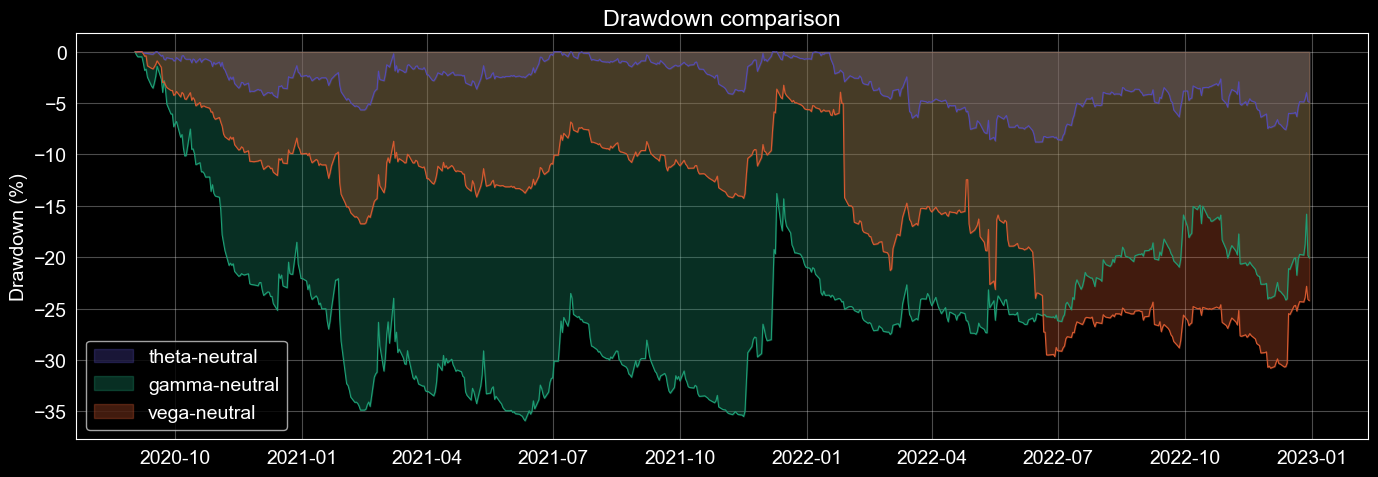

In [54]:
fig, ax = plt.subplots(figsize=(14, 5))

for greek, bt in backtests.items():
    nav = bt.nav["NAV"]
    daily_returns = nav.pct_change().dropna()
    dd = drawdown(daily_returns)
    ax.fill_between(dd.index, dd * 100, 0, alpha=0.3, color=FLAVOR_COLORS[greek], label=f"{greek}-neutral")
    ax.plot(dd.index, dd * 100, color=FLAVOR_COLORS[greek], linewidth=0.8)

ax.set_title("Drawdown comparison")
ax.set_ylabel("Drawdown (%)")
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 5.4 P&L decomposition by greek

The backtester provides a decomposition of P&L into its greek components: delta, gamma, theta, vega, and residual. This helps understand what is driving the P&L for each flavor.

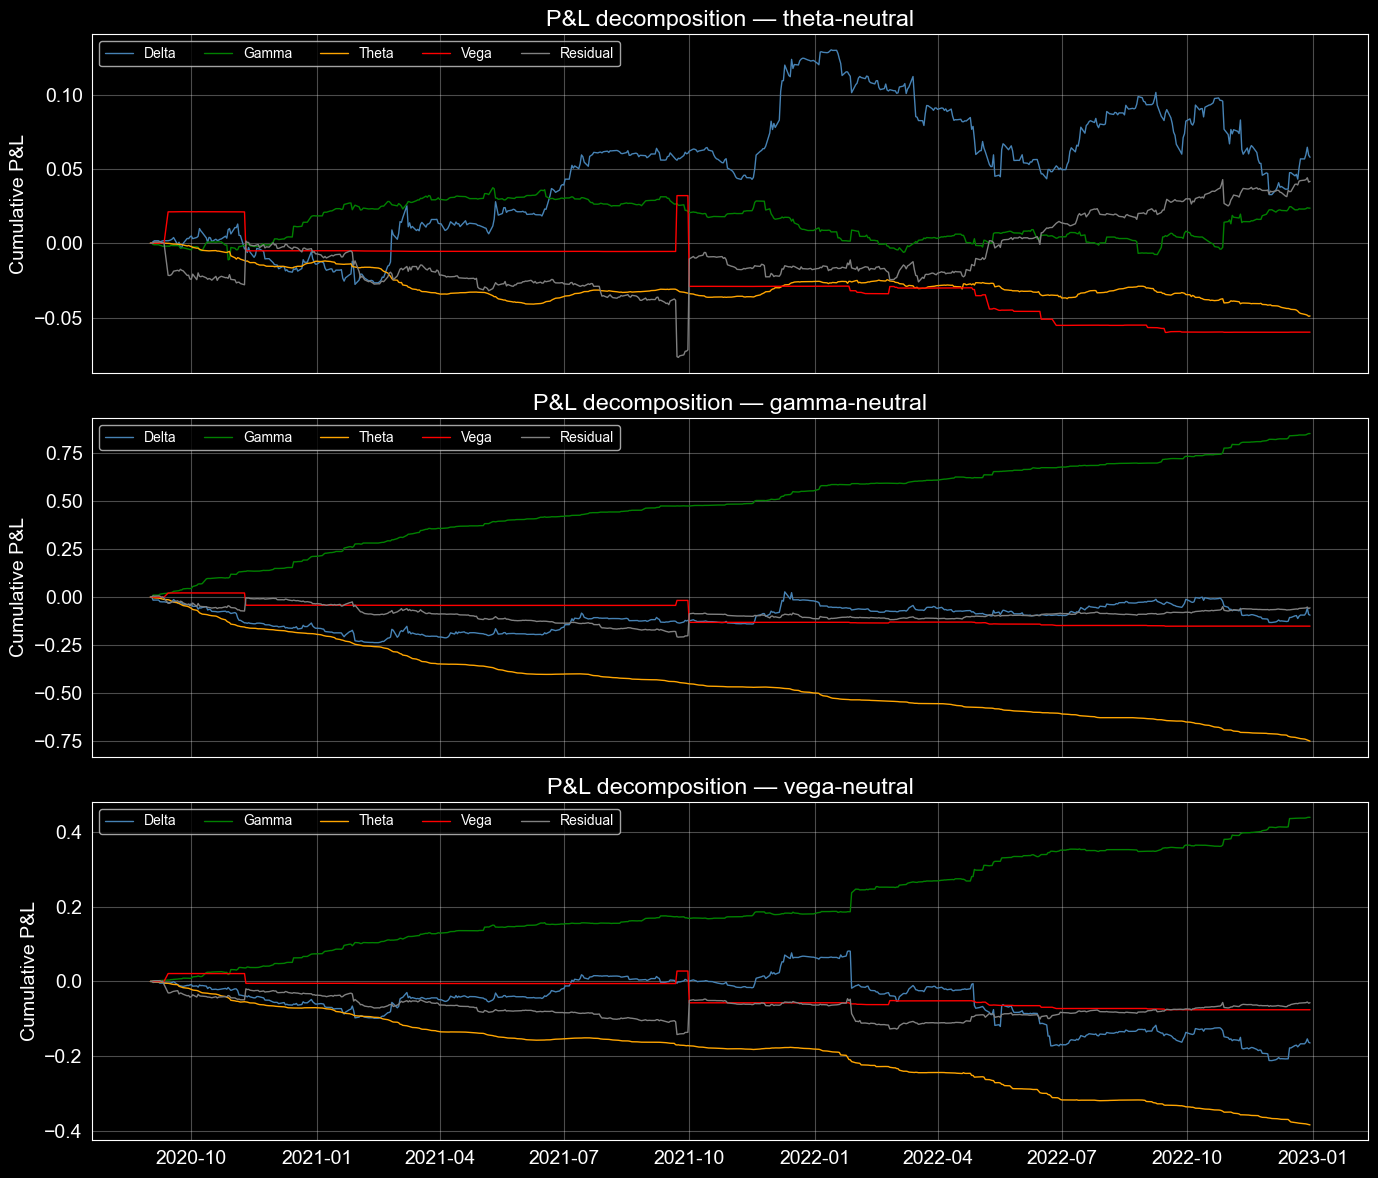

In [55]:
pnl_components = ["delta_pnl", "gamma_pnl", "theta_pnl", "vega_pnl", "residual_pnl"]
pnl_colors = ["steelblue", "green", "orange", "red", "gray"]

fig, axes = plt.subplots(len(backtests), 1, figsize=(14, 4 * len(backtests)), sharex=True)
if len(backtests) == 1:
    axes = [axes]

for ax, (greek, bt) in zip(axes, backtests.items()):
    for comp, color in zip(pnl_components, pnl_colors):
        if comp in bt.pnl.columns:
            cumulative = bt.pnl[comp].cumsum()
            label = comp.replace("_pnl", "").capitalize()
            ax.plot(cumulative.index, cumulative, label=label, color=color, linewidth=1)
    
    ax.set_title(f"P&L decomposition — {greek}-neutral")
    ax.set_ylabel("Cumulative P&L")
    ax.legend(loc="upper left", fontsize=10, ncol=5)
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## 6. Sizing Ratio Analysis

The ratio $N_{\text{AAPL}} / N_{\text{SPY}}$ evolves over time as the greeks change. Let's visualize how each flavor sizes the component leg.

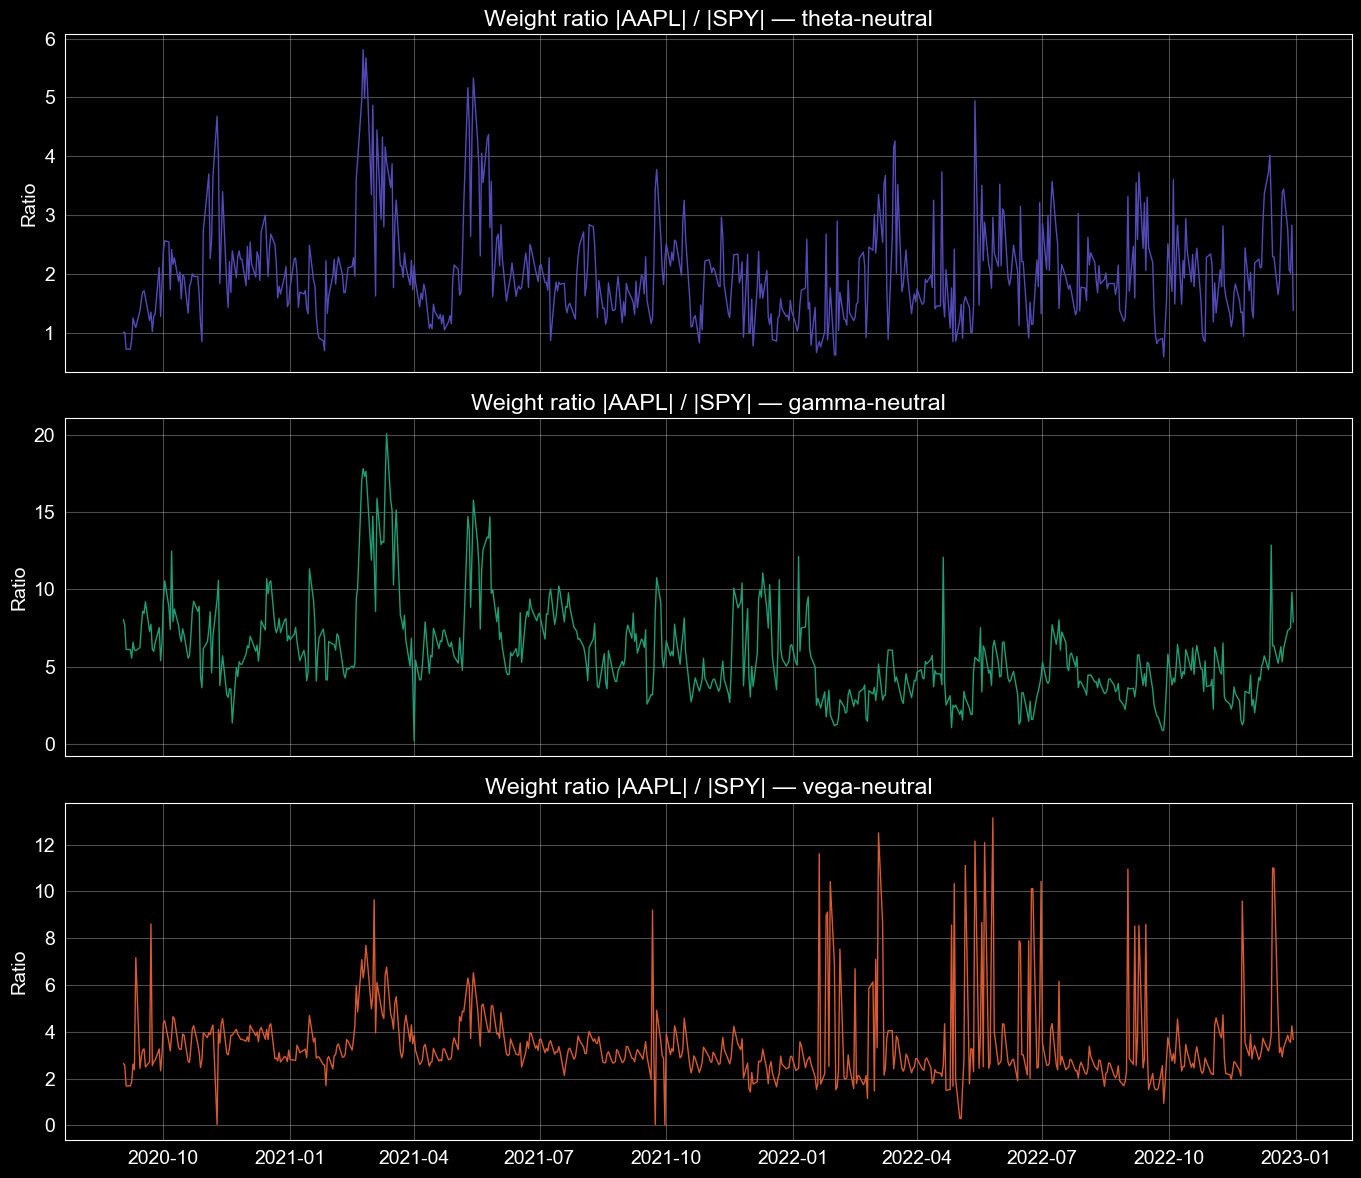

In [56]:
fig, axes = plt.subplots(len(backtests), 1, figsize=(14, 4 * len(backtests)), sharex=True)
if len(backtests) == 1:
    axes = [axes]

for ax, (greek, bt) in zip(axes, backtests.items()):
    dp = bt.drifted_positions
    
    # Component (AAPL) weight per date (sum of all option positions)
    aapl_weight = (
        dp[dp["ticker"] == COMPONENT_TICKER]
        .groupby("date")["scaled_weight"]
        .sum()
    )
    # Index (SPY) weight per date
    spy_weight = (
        dp[dp["ticker"] == INDEX_TICKER]
        .groupby("date")["scaled_weight"]
        .sum()
    )
    
    ratio = aapl_weight.abs() / spy_weight.abs().replace(0, np.nan)
    ratio = ratio.dropna()
    
    ax.plot(ratio.index, ratio, color=FLAVOR_COLORS[greek], linewidth=1)
    ax.set_title(f"Weight ratio |AAPL| / |SPY| — {greek}-neutral")
    ax.set_ylabel("Ratio")
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## 7. Stress Period Analysis — 2022 Bear Market

Since our backtest starts post-AAPL split (September 2020), we cannot observe the Covid crash.
Instead, we zoom into the **2022 bear market** (Jan–June 2022) where correlation spiked due to
the Fed rate hike cycle and tech selloff.

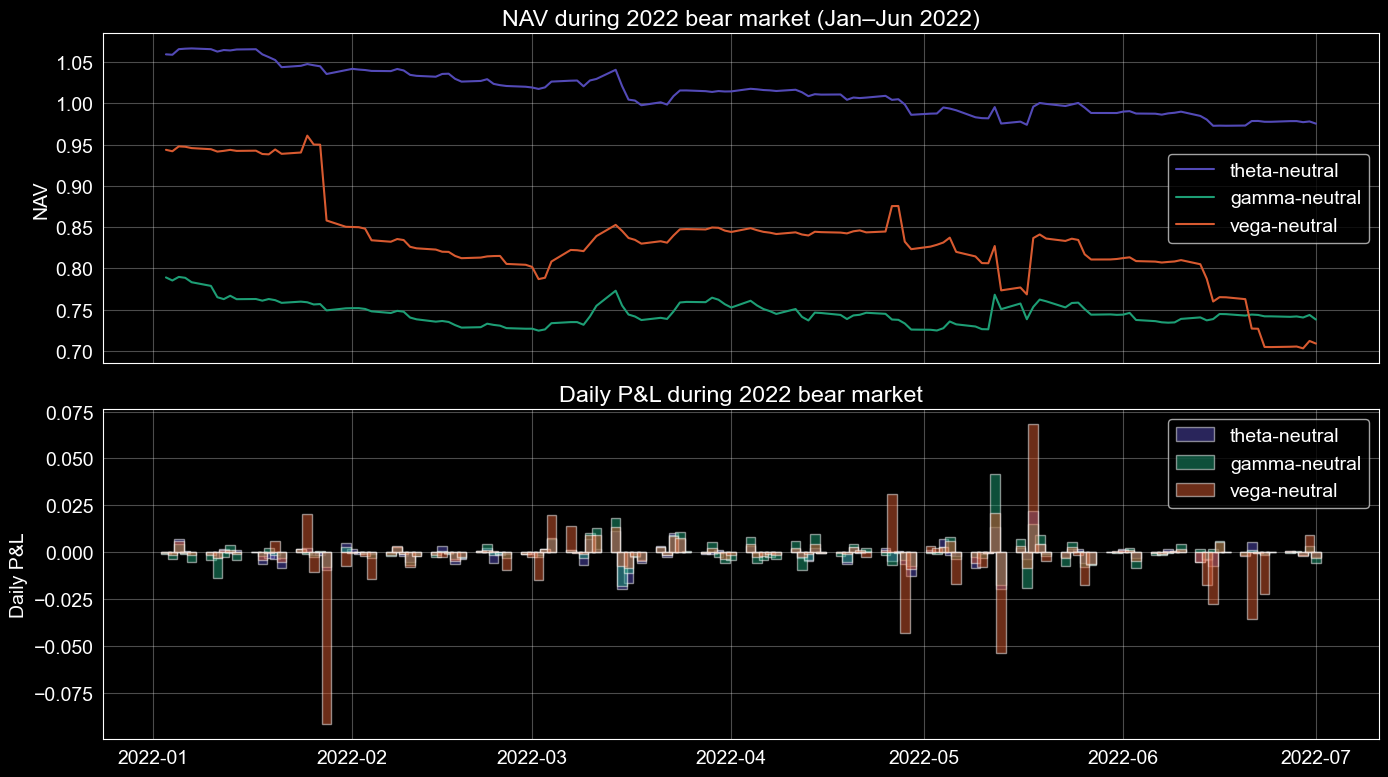

In [57]:
# Stress period zoom: 2022 bear market (Jan-Jun 2022)
crisis_start = datetime(2022, 1, 1)
crisis_end   = datetime(2022, 7, 1)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: NAV during stress
for greek, bt in backtests.items():
    nav = bt.nav["NAV"]
    nav_crisis = nav[(nav.index >= crisis_start) & (nav.index <= crisis_end)]
    axes[0].plot(nav_crisis.index, nav_crisis, label=f"{greek}-neutral",
                 color=FLAVOR_COLORS[greek], linewidth=1.5)

axes[0].set_title("NAV during 2022 bear market (Jan–Jun 2022)")
axes[0].set_ylabel("NAV")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel 2: Daily P&L during stress
for greek, bt in backtests.items():
    pnl = bt.pnl["pnl"]
    pnl_crisis = pnl[(pnl.index >= crisis_start) & (pnl.index <= crisis_end)]
    axes[1].bar(pnl_crisis.index, pnl_crisis, alpha=0.5,
                color=FLAVOR_COLORS[greek], label=f"{greek}-neutral", width=1.5)

axes[1].set_title("Daily P&L during 2022 bear market")
axes[1].set_ylabel("Daily P&L")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## 8. Rolling Correlation: Implied vs Realized

The profitability of dispersion trades is driven by the gap between implied and realized correlation. Let's compute the rolling realized correlation between SPY and AAPL and compare it to the implied volatility spread.

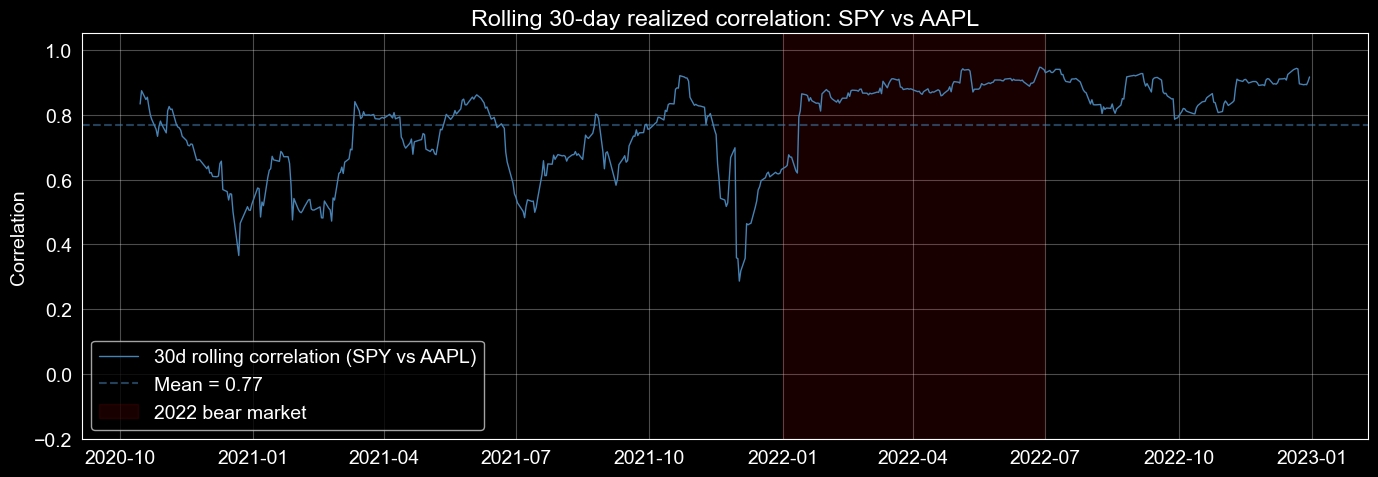

In [58]:
# Compute rolling realized correlation between SPY and AAPL daily returns
spy_returns  = df_spy_spot.set_index("date")["spot"].pct_change().dropna()
aapl_returns = df_aapl_spot.set_index("date")["spot"].pct_change().dropna()

# Align
common_idx = spy_returns.index.intersection(aapl_returns.index)
spy_r  = spy_returns.loc[common_idx]
aapl_r = aapl_returns.loc[common_idx]

rolling_corr = spy_r.rolling(30).corr(aapl_r)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_corr.index, rolling_corr, color="steelblue", linewidth=1, label="30d rolling correlation (SPY vs AAPL)")
ax.axhline(y=rolling_corr.mean(), color="steelblue", linestyle="--", alpha=0.5,
           label=f"Mean = {rolling_corr.mean():.2f}")
ax.axvspan(datetime(2022, 1, 1), datetime(2022, 6, 30), alpha=0.1, color="red", label="2022 bear market")
ax.set_title("Rolling 30-day realized correlation: SPY vs AAPL")
ax.set_ylabel("Correlation")
ax.set_ylim(-0.2, 1.05)
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 9. Monthly Returns Heatmap

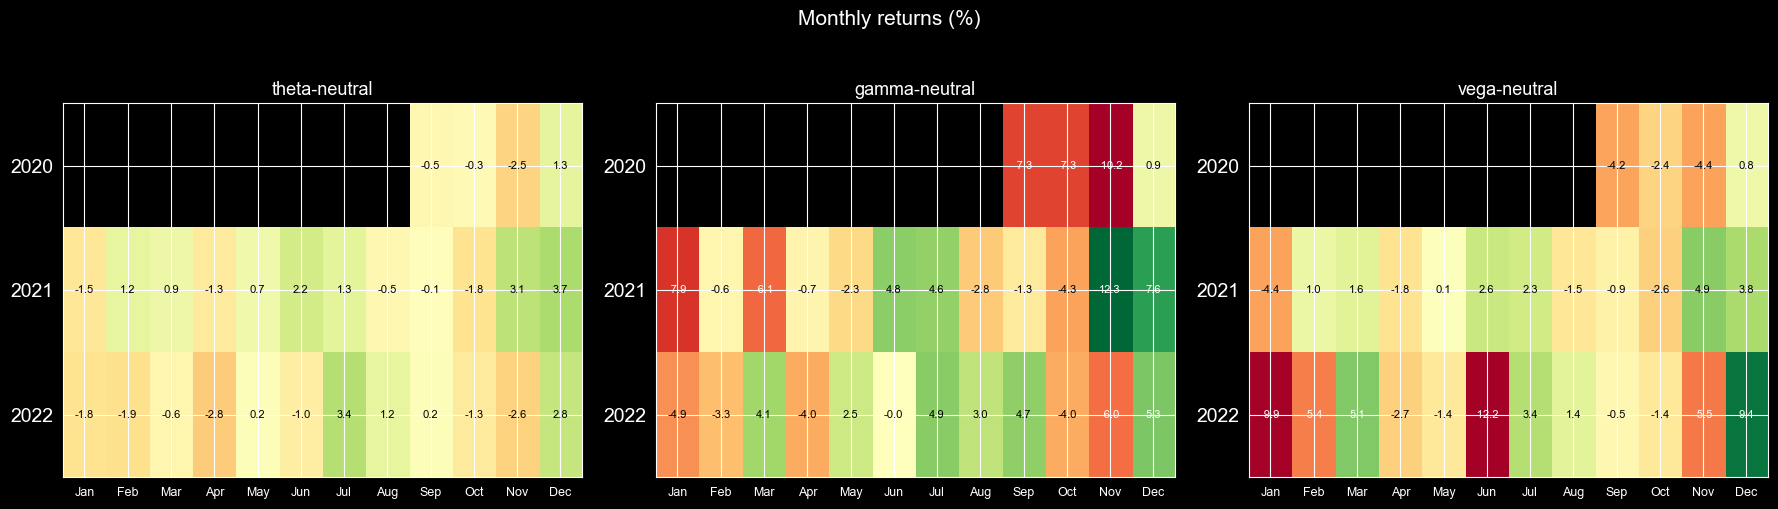

In [59]:
fig, axes = plt.subplots(1, len(backtests), figsize=(6 * len(backtests), 5))
if len(backtests) == 1:
    axes = [axes]

for ax, (greek, bt) in zip(axes, backtests.items()):
    nav = bt.nav["NAV"]
    daily_returns = nav.pct_change().dropna()
    
    monthly = daily_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
    monthly_df = pd.DataFrame({
        "Year": monthly.index.year,
        "Month": monthly.index.month,
        "Return": monthly.values,
    })
    pivot = monthly_df.pivot(index="Year", columns="Month", values="Return") * 100
    pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][:len(pivot.columns)]
    
    im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=-10, vmax=10)
    ax.set_xticks(range(pivot.shape[1])); ax.set_xticklabels(pivot.columns, fontsize=9)
    ax.set_yticks(range(pivot.shape[0])); ax.set_yticklabels(pivot.index)
    ax.set_title(f"{greek}-neutral", fontsize=13)
    
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8,
                        color="white" if abs(val) > 5 else "black")

plt.suptitle("Monthly returns (%)", fontsize=15, y=1.02)
plt.tight_layout(); plt.show()

---
## 10. Return Distribution

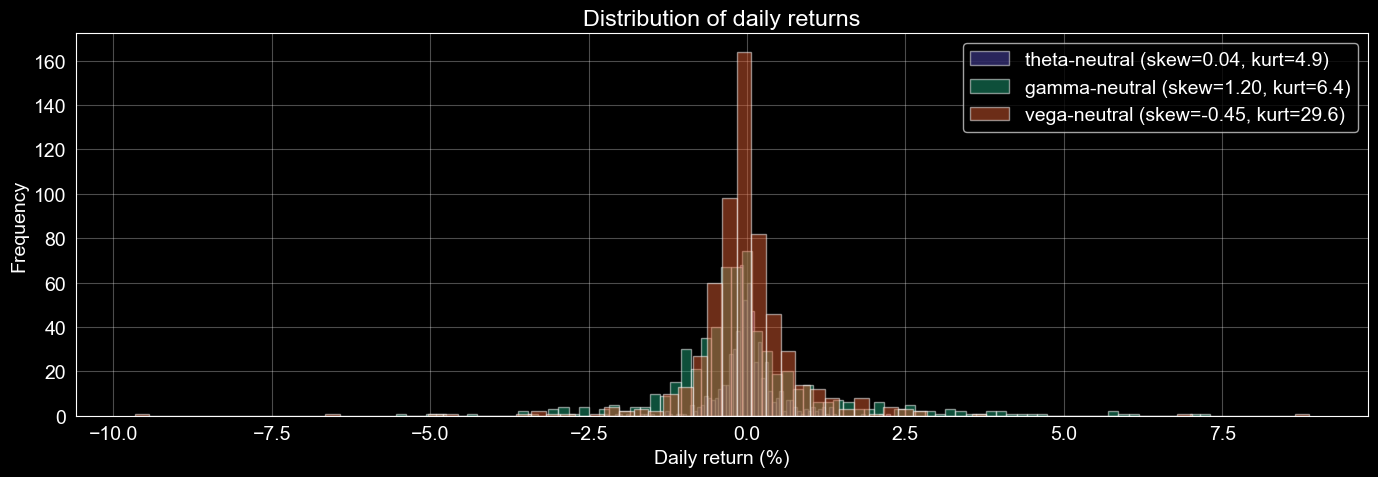

In [60]:
fig, ax = plt.subplots(figsize=(14, 5))

for greek, bt in backtests.items():
    nav = bt.nav["NAV"]
    daily_returns = nav.pct_change().dropna()
    ax.hist(daily_returns * 100, bins=80, alpha=0.5, color=FLAVOR_COLORS[greek],
            label=f"{greek}-neutral (skew={daily_returns.skew():.2f}, kurt={daily_returns.kurtosis():.1f})")

ax.set_title("Distribution of daily returns")
ax.set_xlabel("Daily return (%)")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 11. Conclusion & Discussion

### Key findings

**1. Which flavor is most adapted in practice?**

*(To be completed after running the backtest — discuss trade-offs between theta-neutral carry isolation vs gamma-neutral P&L convexity vs vega-neutral pure correlation exposure.)*

**2. Is the trade profitable over the test period?**

*(Refer to the performance metrics table above. Discuss the Sharpe ratio and whether the returns compensate for the tail risk observed in March 2020.)*

**3. Do we confirm the existence of the correlation risk premium (Driessen et al., 2009)?**

*(Look at the rolling correlation chart: is the average realized correlation consistently below what would be implied by index vs single-stock implied vols? Does the P&L pattern confirm carry collection with occasional correlation spike drawdowns?)*

**4. Limitations**

- **Single component**: We only trade AAPL vs SPY. A real dispersion trade uses a basket of components.
- **Transaction costs**: We include bid-ask spread but not slippage or market impact.
- **Rebalancing frequency**: Weekly (Wednesday) — could be optimized.
- **No implied correlation model**: We use raw greek ratios rather than an explicit implied correlation surface.

**5. Possible extensions**

- Multi-component basket (top-N S&P 500 stocks)
- Dynamic flavor selection (switch between θ and Γ based on vol regime)
- Regime-conditional sizing (smaller when VIX is above 30)
- Explicit implied vs realized correlation tracking